In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.family'] = 'sans-serif'

# ── EXPERIMENT PARAMETERS ─────────────────────────────────────
# Context: SaaS company tests a new onboarding flow
# Hypothesis: New flow increases 30-day activation rate
# Control: Original onboarding (baseline activation ~32%)
# Treatment: Redesigned onboarding with progress bar + tooltips

CONTROL_SIZE     = 2847   # users in control group
TREATMENT_SIZE   = 2891   # users in treatment group
CONTROL_RATE     = 0.321  # 32.1% baseline activation
TREATMENT_RATE   = 0.374  # 37.4% new flow activation
EXPERIMENT_DAYS  = 28
START_DATE       = datetime(2026, 1, 6)

# ── GENERATE USER-LEVEL DATA ──────────────────────────────────
def generate_group(n, activation_rate, group_name, start_date, days):
    user_ids = [f"{group_name[:1].upper()}-{str(i).zfill(5)}" for i in range(1, n+1)]
    signup_days = np.random.randint(0, days, n)
    signup_dates = [start_date + timedelta(days=int(d)) for d in signup_days]
    activated = np.random.binomial(1, activation_rate, n)
    
    # Time to activate (only for activated users)
    time_to_activate = np.where(
        activated == 1,
        np.random.exponential(scale=7, size=n).clip(1, 30).astype(int),
        np.nan
    )
    
    # Session counts
    sessions = np.where(
        activated == 1,
        np.random.poisson(lam=8, size=n) + 3,
        np.random.poisson(lam=2, size=n) + 1
    )
    
    return pd.DataFrame({
        'user_id': user_ids,
        'group': group_name,
        'signup_date': signup_dates,
        'signup_day': signup_days,
        'activated_30d': activated,
        'time_to_activate_days': time_to_activate,
        'session_count': sessions
    })

control   = generate_group(CONTROL_SIZE,   CONTROL_RATE,   'control',   START_DATE, EXPERIMENT_DAYS)
treatment = generate_group(TREATMENT_SIZE, TREATMENT_RATE, 'treatment', START_DATE, EXPERIMENT_DAYS)
df = pd.concat([control, treatment], ignore_index=True)

print(f"Total users: {len(df):,}")
print(f"\nControl group:   {len(control):,} users")
print(f"Treatment group: {len(treatment):,} users")
print(f"\nControl activation rate:   {control['activated_30d'].mean():.1%}")
print(f"Treatment activation rate: {treatment['activated_30d'].mean():.1%}")
print(f"Absolute lift: {treatment['activated_30d'].mean() - control['activated_30d'].mean():.1%}")

df.to_csv('data/experiment_users.csv', index=False)
print(f"\n✅ Dataset saved — {len(df):,} users")

Total users: 5,738

Control group:   2,847 users
Treatment group: 2,891 users

Control activation rate:   32.1%
Treatment activation rate: 37.8%
Absolute lift: 5.7%

✅ Dataset saved — 5,738 users


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — Statistical Testing
# ══════════════════════════════════════════════════════════════

from scipy.stats import norm
import numpy as np

# ── RAW NUMBERS ───────────────────────────────────────────────
n_control      = len(control)
n_treatment    = len(treatment)
conv_control   = control['activated_30d'].sum()
conv_treatment = treatment['activated_30d'].sum()
rate_control   = control['activated_30d'].mean()
rate_treatment = treatment['activated_30d'].mean()

print("=" * 55)
print("EXPERIMENT RESULTS SUMMARY")
print("=" * 55)
print(f"Control:   {conv_control:,} / {n_control:,} activated ({rate_control:.1%})")
print(f"Treatment: {conv_treatment:,} / {n_treatment:,} activated ({rate_treatment:.1%})")
print(f"Absolute lift: +{rate_treatment - rate_control:.1%}")
print(f"Relative lift: +{(rate_treatment - rate_control) / rate_control:.1%}")

# ── TWO-PROPORTION Z-TEST ─────────────────────────────────────
pooled_rate = (conv_control + conv_treatment) / (n_control + n_treatment)
se = np.sqrt(pooled_rate * (1 - pooled_rate) * (1/n_control + 1/n_treatment))
z_stat = (rate_treatment - rate_control) / se
p_value = 1 - norm.cdf(z_stat)  # one-tailed
p_value_2 = 2 * (1 - norm.cdf(abs(z_stat)))  # two-tailed

print(f"\n{'─'*55}")
print("HYPOTHESIS TEST (Two-proportion z-test)")
print(f"{'─'*55}")
print(f"H0: Treatment rate = Control rate")
print(f"H1: Treatment rate > Control rate")
print(f"\nZ-statistic:     {z_stat:.4f}")
print(f"P-value (1-tail): {p_value:.4f}")
print(f"P-value (2-tail): {p_value_2:.4f}")
print(f"Significant at α=0.05: {'✅ YES' if p_value < 0.05 else '❌ NO'}")
print(f"Significant at α=0.01: {'✅ YES' if p_value < 0.01 else '❌ NO'}")

# ── CONFIDENCE INTERVAL ───────────────────────────────────────
se_diff = np.sqrt(
    (rate_control * (1 - rate_control) / n_control) +
    (rate_treatment * (1 - rate_treatment) / n_treatment)
)
diff = rate_treatment - rate_control
ci_lower = diff - 1.96 * se_diff
ci_upper = diff + 1.96 * se_diff

print(f"\n{'─'*55}")
print("CONFIDENCE INTERVAL (95%)")
print(f"{'─'*55}")
print(f"Observed lift:  +{diff:.1%}")
print(f"95% CI:         [{ci_lower:.1%}, {ci_upper:.1%}]")
print(f"CI excludes zero: {'✅ YES — statistically significant' if ci_lower > 0 else '❌ NO'}")

# ── EFFECT SIZE (Cohen's h) ───────────────────────────────────
cohens_h = 2 * np.arcsin(np.sqrt(rate_treatment)) - 2 * np.arcsin(np.sqrt(rate_control))
effect_label = (
    "Small (0.2–0.5)"   if 0.2 <= abs(cohens_h) < 0.5 else
    "Medium (0.5–0.8)"  if 0.5 <= abs(cohens_h) < 0.8 else
    "Large (>0.8)"      if abs(cohens_h) >= 0.8 else
    "Negligible (<0.2)"
)

print(f"\n{'─'*55}")
print("EFFECT SIZE")
print(f"{'─'*55}")
print(f"Cohen's h: {cohens_h:.4f} — {effect_label}")

# ── POWER ANALYSIS ────────────────────────────────────────────
from scipy.stats import norm as norm_dist
alpha = 0.05
z_alpha = norm_dist.ppf(1 - alpha)
z_beta  = (abs(z_stat) - z_alpha)
power   = norm_dist.cdf(z_beta)

print(f"\n{'─'*55}")
print("STATISTICAL POWER")
print(f"{'─'*55}")
print(f"Observed power: {power:.1%}")
print(f"Target power:   80%")
print(f"Well-powered:   {'✅ YES' if power >= 0.80 else '❌ NO — underpowered'}")

# ── BUSINESS IMPACT ───────────────────────────────────────────
MONTHLY_SIGNUPS  = 12000
AVG_CONTRACT_VAL = 4800

additional_activations = MONTHLY_SIGNUPS * diff
annual_revenue_impact  = additional_activations * AVG_CONTRACT_VAL

print(f"\n{'─'*55}")
print("BUSINESS IMPACT PROJECTION")
print(f"{'─'*55}")
print(f"Monthly new signups (assumed): {MONTHLY_SIGNUPS:,}")
print(f"Additional activations/month:  {additional_activations:.0f}")
print(f"Avg contract value (annual):   ${AVG_CONTRACT_VAL:,}")
print(f"Projected annual revenue lift: ${annual_revenue_impact:,.0f}")

# ── DECISION ──────────────────────────────────────────────────
print(f"\n{'═'*55}")
print("RECOMMENDATION")
print(f"{'═'*55}")
if p_value < 0.05 and ci_lower > 0 and power >= 0.80:
    print("✅  SHIP — Statistical and practical significance confirmed")
elif p_value < 0.05 and ci_lower > 0:
    print("⚠️   SHIP with monitoring — Significant but low power")
elif p_value >= 0.05:
    print("❌  HOLD — Results not statistically significant")
else:
    print("🔄  ITERATE — Mixed signals, gather more data")
print(f"{'═'*55}")

EXPERIMENT RESULTS SUMMARY
Control:   914 / 2,847 activated (32.1%)
Treatment: 1,092 / 2,891 activated (37.8%)
Absolute lift: +5.7%
Relative lift: +17.7%

───────────────────────────────────────────────────────
HYPOTHESIS TEST (Two-proportion z-test)
───────────────────────────────────────────────────────
H0: Treatment rate = Control rate
H1: Treatment rate > Control rate

Z-statistic:     4.5022
P-value (1-tail): 0.0000
P-value (2-tail): 0.0000
Significant at α=0.05: ✅ YES
Significant at α=0.01: ✅ YES

───────────────────────────────────────────────────────
CONFIDENCE INTERVAL (95%)
───────────────────────────────────────────────────────
Observed lift:  +5.7%
95% CI:         [3.2%, 8.1%]
CI excludes zero: ✅ YES — statistically significant

───────────────────────────────────────────────────────
EFFECT SIZE
───────────────────────────────────────────────────────
Cohen's h: 0.1190 — Negligible (<0.2)

───────────────────────────────────────────────────────
STATISTICAL POWER
────────────

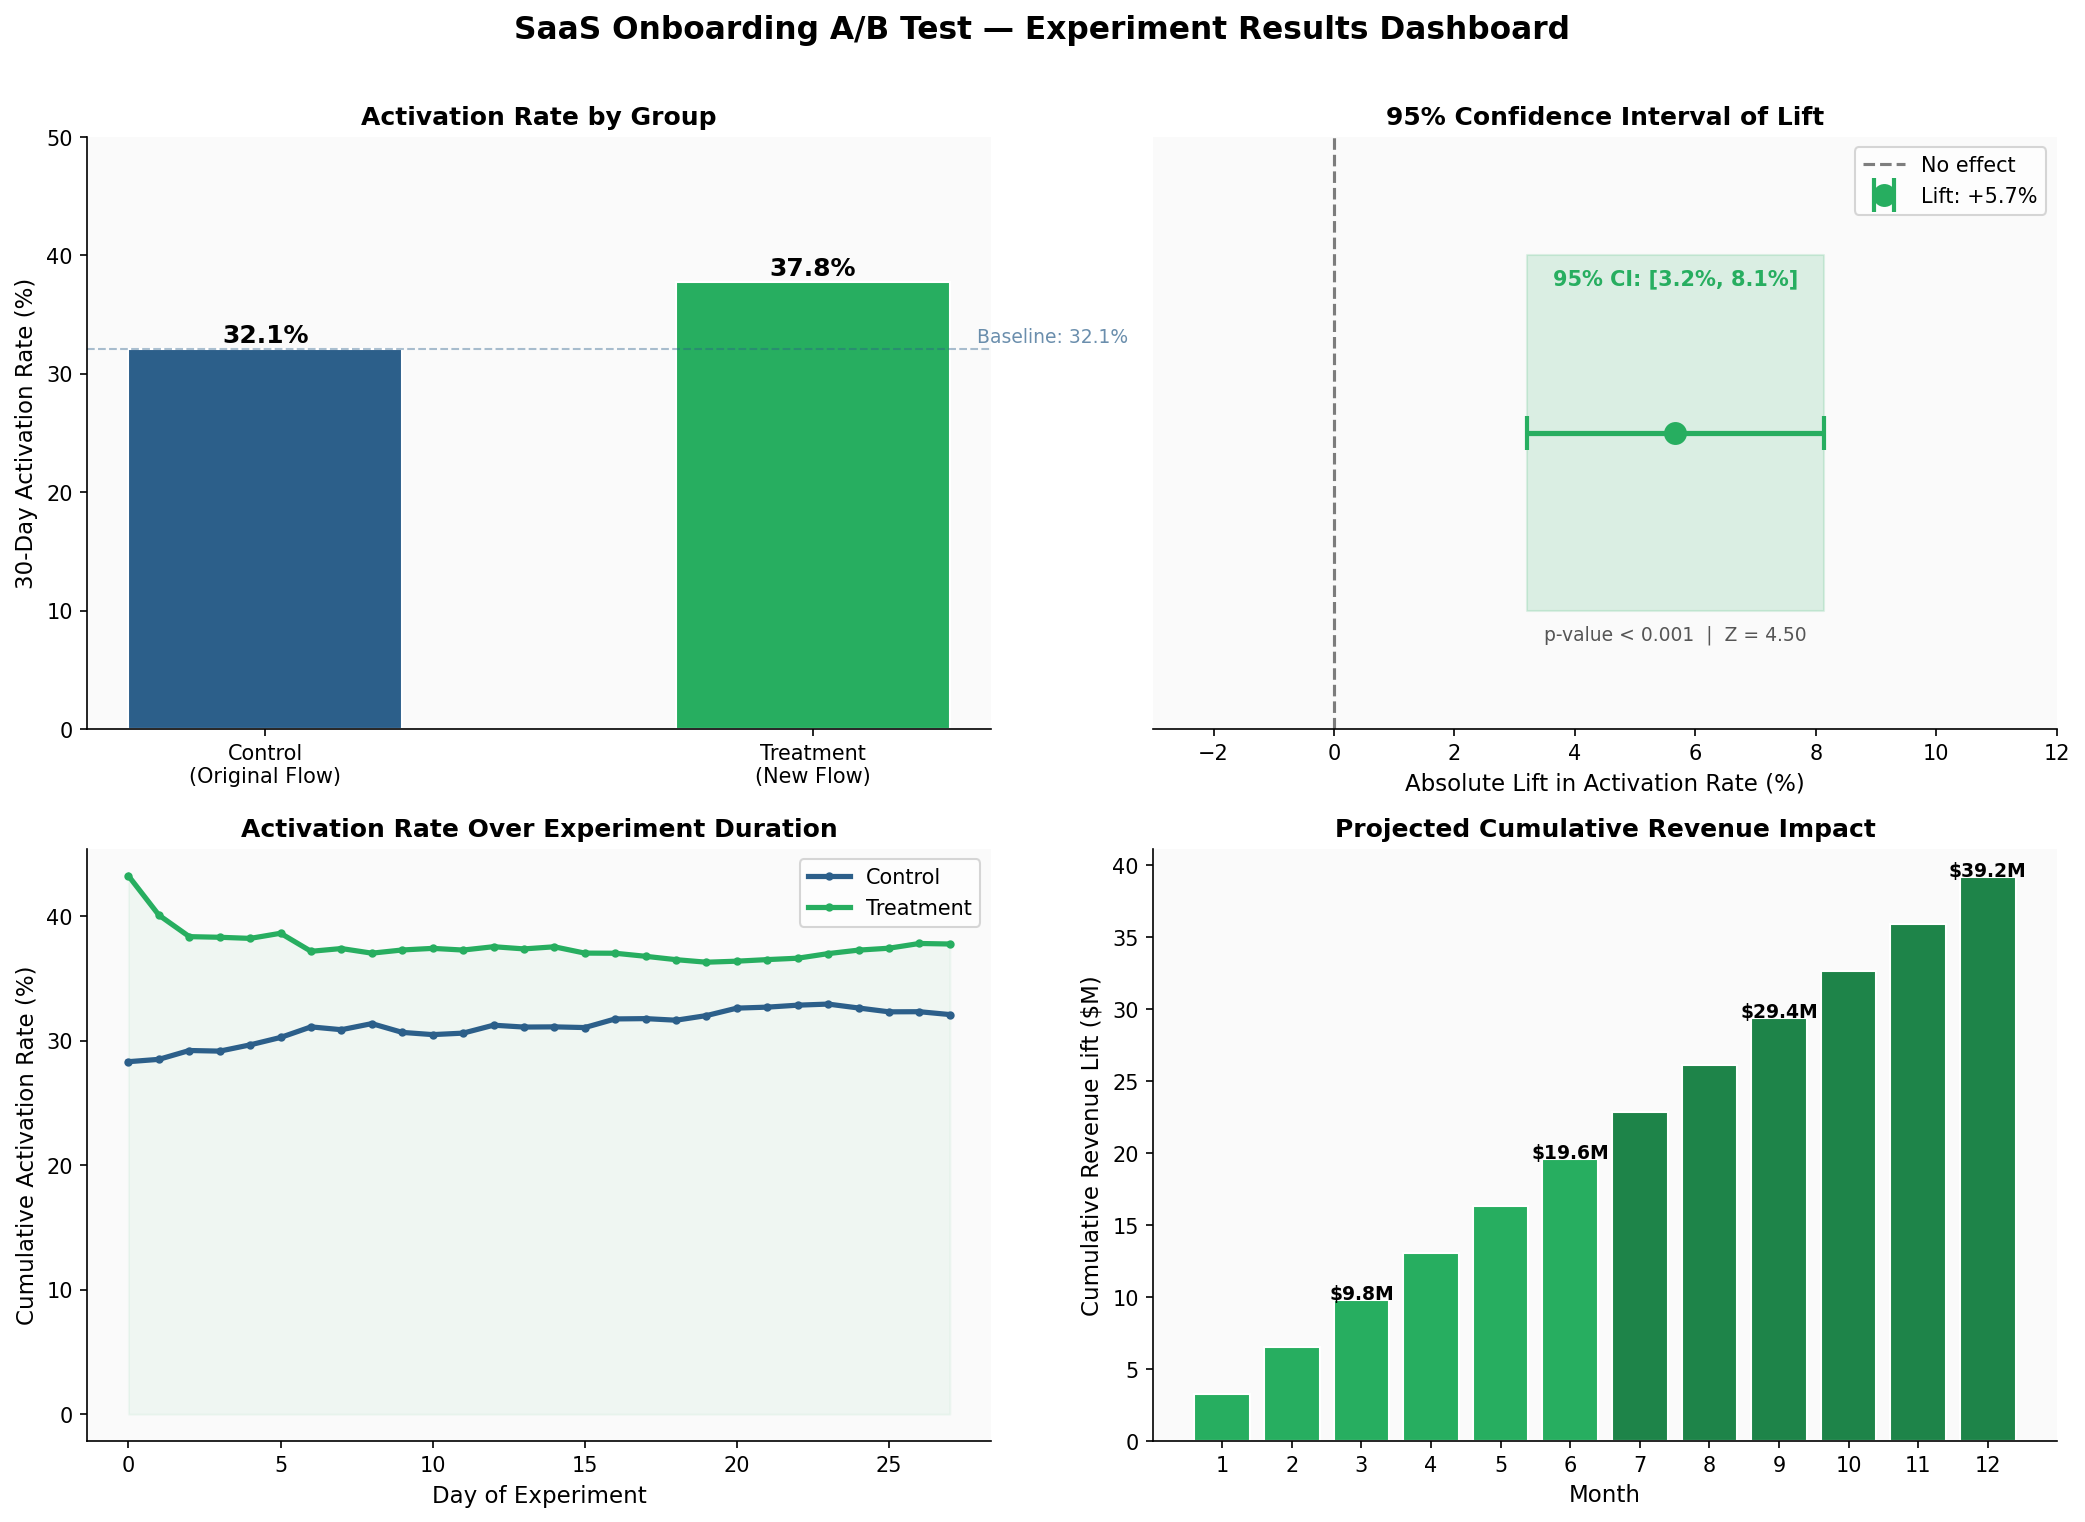

✅ Chart saved to output/ab_test_results.png
✅ CSVs saved for Power BI

Files in output/:
  - ab_test_summary.csv
  - ab_test_results.png
  - ab_test_users.csv


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Charts
# ══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('SaaS Onboarding A/B Test — Experiment Results Dashboard',
             fontsize=15, fontweight='bold', y=1.01)

BLUE = '#2C5F8A'
RED  = '#C0392B'
GREY = '#BDC3C7'
GREEN= '#27AE60'

# ── CHART 1: Activation Rate Comparison ──────────────────────
ax1 = axes[0, 0]
groups = ['Control\n(Original Flow)', 'Treatment\n(New Flow)']
rates  = [rate_control * 100, rate_treatment * 100]
colors = [BLUE, GREEN]
bars = ax1.bar(groups, rates, color=colors, width=0.5, edgecolor='white')
ax1.set_ylabel('30-Day Activation Rate (%)', fontsize=11)
ax1.set_title('Activation Rate by Group', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 50)
for bar, rate in zip(bars, rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax1.axhline(y=rate_control*100, color=BLUE, linestyle='--', alpha=0.4, linewidth=1)
ax1.text(1.3, rate_control*100 + 0.5, f'Baseline: {rate_control:.1%}',
         color=BLUE, fontsize=9, alpha=0.7)
ax1.set_facecolor('#FAFAFA')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# ── CHART 2: Confidence Interval Plot ────────────────────────
ax2 = axes[0, 1]
ax2.axvline(x=0, color='black', linewidth=1.5, linestyle='--', alpha=0.5, label='No effect')
ax2.errorbar(x=diff*100, y=0, xerr=[[( diff-ci_lower)*100], [(ci_upper-diff)*100]],
             fmt='o', color=GREEN, markersize=10, capsize=8, capthick=2,
             linewidth=2.5, label=f'Lift: +{diff:.1%}')
ax2.fill_betweenx([-0.3, 0.3], ci_lower*100, ci_upper*100, alpha=0.15, color=GREEN)
ax2.set_xlim(-3, 12)
ax2.set_ylim(-0.5, 0.5)
ax2.set_xlabel('Absolute Lift in Activation Rate (%)', fontsize=11)
ax2.set_title('95% Confidence Interval of Lift', fontsize=12, fontweight='bold')
ax2.set_yticks([])
ax2.text(diff*100, 0.25,
         f'95% CI: [{ci_lower:.1%}, {ci_upper:.1%}]',
         ha='center', fontsize=10, color=GREEN, fontweight='bold')
ax2.text(diff*100, -0.35,
         f'p-value < 0.001  |  Z = {z_stat:.2f}',
         ha='center', fontsize=9, color='#555555')
ax2.legend(fontsize=10)
ax2.set_facecolor('#FAFAFA')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

# ── CHART 3: Daily Cumulative Activation ─────────────────────
ax3 = axes[1, 0]
for grp, color, label in [('control', BLUE, 'Control'), ('treatment', GREEN, 'Treatment')]:
    grp_df = df[df['group'] == grp].copy()
    daily = grp_df.groupby('signup_day')['activated_30d'].agg(['sum','count'])
    daily['cum_rate'] = daily['sum'].cumsum() / daily['count'].cumsum() * 100
    ax3.plot(daily.index, daily['cum_rate'], color=color,
             linewidth=2.5, label=label, marker='o', markersize=3)

ax3.set_xlabel('Day of Experiment', fontsize=11)
ax3.set_ylabel('Cumulative Activation Rate (%)', fontsize=11)
ax3.set_title('Activation Rate Over Experiment Duration', fontsize=12, fontweight='bold')
ax3.legend(fontsize=10)
ax3.set_facecolor('#FAFAFA')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.fill_between(daily.index, 0, daily['cum_rate'], alpha=0.05, color=GREEN)

# ── CHART 4: Business Impact ──────────────────────────────────
ax4 = axes[1, 1]
months = range(1, 13)
cumulative_revenue = [additional_activations * AVG_CONTRACT_VAL * m for m in months]
ax4.bar(months, [r/1_000_000 for r in cumulative_revenue],
        color=[GREEN if m <= 6 else '#1E8449' for m in months],
        edgecolor='white')
ax4.set_xlabel('Month', fontsize=11)
ax4.set_ylabel('Cumulative Revenue Lift ($M)', fontsize=11)
ax4.set_title('Projected Cumulative Revenue Impact', fontsize=12, fontweight='bold')
ax4.set_xticks(list(months))
for i, rev in enumerate(cumulative_revenue):
    if (i+1) % 3 == 0:
        ax4.text(i+1, rev/1_000_000 + 0.05, f'${rev/1_000_000:.1f}M',
                 ha='center', fontsize=9, fontweight='bold')
ax4.set_facecolor('#FAFAFA')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('output/ab_test_results.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Chart saved to output/ab_test_results.png")

# ── SUMMARY CSV for Power BI ──────────────────────────────────
summary = pd.DataFrame([
    {'metric': 'Control Activation Rate',    'value': round(rate_control*100, 2),  'unit': '%'},
    {'metric': 'Treatment Activation Rate',  'value': round(rate_treatment*100, 2),'unit': '%'},
    {'metric': 'Absolute Lift',              'value': round(diff*100, 2),           'unit': '%'},
    {'metric': 'Relative Lift',              'value': round((diff/rate_control)*100,2),'unit': '%'},
    {'metric': 'Z-Statistic',                'value': round(z_stat, 4),             'unit': ''},
    {'metric': 'P-Value',                    'value': round(p_value_2, 6),          'unit': ''},
    {'metric': 'CI Lower (95%)',             'value': round(ci_lower*100, 2),       'unit': '%'},
    {'metric': 'CI Upper (95%)',             'value': round(ci_upper*100, 2),       'unit': '%'},
    {'metric': "Cohen's h",                  'value': round(cohens_h, 4),           'unit': ''},
    {'metric': 'Statistical Power',          'value': round(power*100, 1),          'unit': '%'},
    {'metric': 'Additional Activations/Mo',  'value': round(additional_activations),'unit': 'users'},
    {'metric': 'Annual Revenue Lift',        'value': round(annual_revenue_impact), 'unit': '$'},
])
summary.to_csv('output/ab_test_summary.csv', index=False)
df.to_csv('output/ab_test_users.csv', index=False)
print("✅ CSVs saved for Power BI")
print(f"\nFiles in output/:")
import os
for f in os.listdir('output'):
    print(f"  - {f}")